# Business Problem

Car resale platforms like CarDekho need accurate pricing models to:

- Help sellers price vehicles competitively
- Assist buyers in evaluating fair market value
- Increase trust and transaction efficiency

Objective :
Build a machine learning model to predict the selling price of used cars based on vehicle attributes.

In [235]:
import numpy as np
import pandas as pd

In [236]:
df = pd.DataFrame(pd.read_csv('cardekho_imputated.csv'))

# 📊 Dataset Overview

The dataset contains used car listings with the following features:

- car_name	
- brand	
- model	
- vehicle_age	
- km_driven	
- seller_type	
- fuel_type	
- transmission_type	
- mileage	engine	
- max_power	
- seats
- Selling Price (Target Variable)

We aim to predict: **Selling Price**

In [237]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [238]:
df.shape

(15411, 14)

In [239]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [240]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


# Data Visualization

In [241]:
print(len(df['car_name'].unique()), "types of cars")
print(len(df['brand'].unique()), "brands")
print(len(df['model'].unique()), "models")
print(len(df['seller_type'].unique()), "seller types")
print(len(df['fuel_type'].unique()), "fuel types")
print(len(df['transmission_type'].unique()), "transmission types")

121 types of cars
32 brands
120 models
3 seller types
5 fuel types
2 transmission types


In [242]:
df['fuel_type'].value_counts()

fuel_type
Petrol      7643
Diesel      7419
CNG          301
LPG           44
Electric       4
Name: count, dtype: int64

In [243]:
df['seller_type'].value_counts()

seller_type
Dealer              9539
Individual          5699
Trustmark Dealer     173
Name: count, dtype: int64

In [244]:
df['fuel_type'].value_counts()


fuel_type
Petrol      7643
Diesel      7419
CNG          301
LPG           44
Electric       4
Name: count, dtype: int64

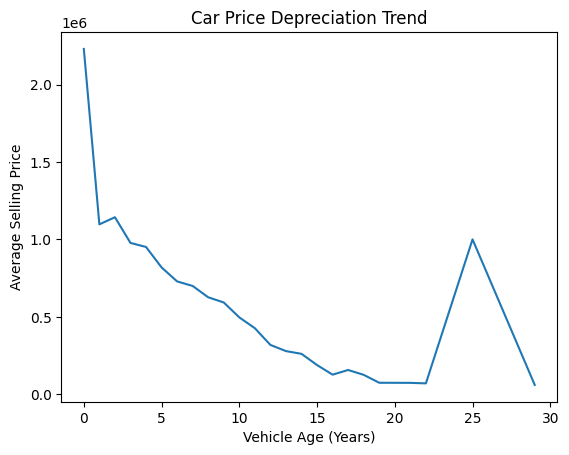

In [245]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
# df = pd.read_csv("cars.csv")

# Group by vehicle_age
age_price = df.groupby("vehicle_age")["selling_price"].mean().reset_index()

# Sort by vehicle_age
age_price = age_price.sort_values("vehicle_age")

# Plot stock-style line chart
plt.figure()
plt.plot(age_price["vehicle_age"], age_price["selling_price"])
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Average Selling Price")
plt.title("Car Price Depreciation Trend")
plt.show()

In [246]:
df[df["vehicle_age"] == 25]

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
15329,19439,BMW 3,BMW,3,25,50000,Individual,Petrol,Automatic,11.9,1995,154.0,5,1000000


In [247]:
df["vehicle_age"].value_counts().sort_index()

vehicle_age
0        5
1      221
2     1145
3     1926
4     2252
5     2117
6     1924
7     1438
8     1282
9     1027
10     710
11     551
12     293
13     237
14     129
15      90
16      25
17      17
18      11
19       5
21       3
22       1
25       1
29       1
Name: count, dtype: int64

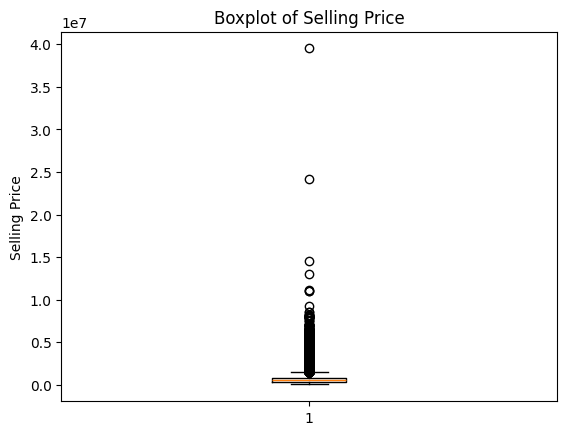

In [248]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df["selling_price"])
plt.title("Boxplot of Selling Price")
plt.ylabel("Selling Price")
plt.show()

<Figure size 640x480 with 0 Axes>

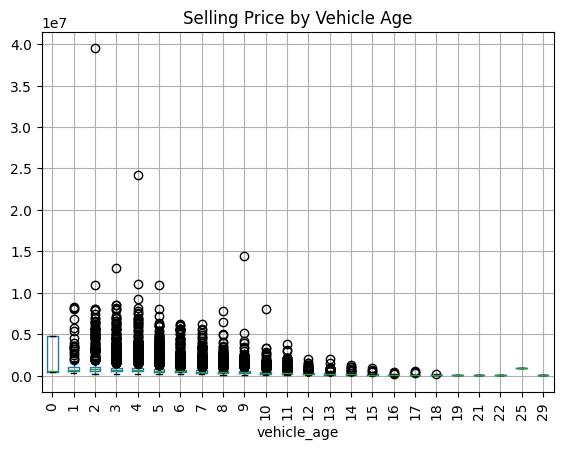

In [249]:
plt.figure()
df.boxplot(column="selling_price", by="vehicle_age")
plt.xticks(rotation=90)
plt.title("Selling Price by Vehicle Age")
plt.suptitle("")
plt.show()

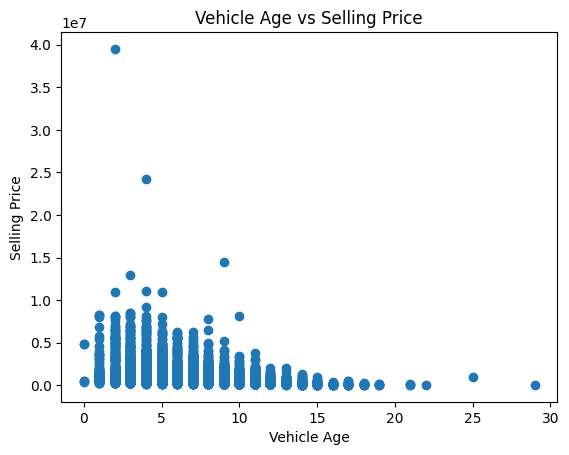

In [250]:
plt.figure()
plt.scatter(df["vehicle_age"], df["selling_price"])
plt.xlabel("Vehicle Age")
plt.ylabel("Selling Price")
plt.title("Vehicle Age vs Selling Price")
plt.show()

In [251]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [252]:
df[(df['selling_price'] > 450000) & (df['selling_price'] < 500000)]
df[(df['selling_price'] > 4000000)]

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
285,367,Land Rover Rover,Land Rover,Rover,3,13000,Dealer,Petrol,Automatic,12.19,1997,237.36,4,7000000
311,397,BMW Z4,BMW,Z4,1,2000,Dealer,Petrol,Automatic,11.29,2998,335.00,2,8250000
318,405,Land Rover Rover,Land Rover,Rover,3,25000,Individual,Petrol,Automatic,9.17,2995,335.25,7,6200000
323,416,BMW 6,BMW,6,3,30000,Individual,Petrol,Automatic,14.28,1998,254.70,4,5500000
351,450,BMW X5,BMW,X5,2,19000,Individual,Diesel,Automatic,13.38,2993,265.00,5,7900000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15129,19189,Jeep Wrangler,Jeep,Wrangler,2,32000,Dealer,Petrol,Automatic,9.50,3604,280.00,5,5600000
15189,19261,Audi A6,Audi,A6,3,5333,Dealer,Petrol,Automatic,13.53,1984,177.01,5,4595000
15251,19338,Mercedes-Benz GLS,Mercedes-Benz,GLS,3,15000,Dealer,Diesel,Automatic,11.00,2987,258.00,7,8000000
15287,19384,BMW 5,BMW,5,2,4000,Dealer,Diesel,Automatic,18.12,1995,190.00,5,5295000


In [253]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [254]:
df[df['seats'] == 0]
# Honda City
# Nissan Kicks

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
3217,4098,Honda City,Honda,City,18,40000,Individual,Petrol,Manual,13.00,1493,100.00,0,115000
12619,15992,Nissan Kicks,Nissan,Kicks,2,10000,Individual,Diesel,Manual,19.39,1461,108.49,0,1154000


In [255]:
df[(df['car_name'] == 'Honda City') & (df['seats'] == 0)]
# Honda City
# Nissan Kicks

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
3217,4098,Honda City,Honda,City,18,40000,Individual,Petrol,Manual,13.0,1493,100.0,0,115000


In [256]:
df[df['seats'] == 0]

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
3217,4098,Honda City,Honda,City,18,40000,Individual,Petrol,Manual,13.00,1493,100.00,0,115000
12619,15992,Nissan Kicks,Nissan,Kicks,2,10000,Individual,Diesel,Manual,19.39,1461,108.49,0,1154000


In [257]:
df[(df['car_name'] == 'Honda City') & (df['seats'] == 0)]

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
3217,4098,Honda City,Honda,City,18,40000,Individual,Petrol,Manual,13.0,1493,100.0,0,115000


In [258]:
df[df['mileage'] < 10].head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
318,405,Land Rover Rover,Land Rover,Rover,3,25000,Individual,Petrol,Automatic,9.17,2995,335.25,7,6200000
646,820,Jeep Wrangler,Jeep,Wrangler,4,40000,Dealer,Petrol,Automatic,9.50,3604,280.00,5,4875000
973,1251,BMW 7,BMW,7,13,70000,Dealer,Petrol,Automatic,8.45,2979,321.00,5,750000
1041,1342,BMW 6,BMW,6,6,25000,Dealer,Diesel,Automatic,9.52,2993,313.00,4,4490000
1172,1508,Bentley Continental,Bentley,Continental,9,9000,Dealer,Petrol,Automatic,9.50,5998,626.00,4,14500000


In [259]:
np.sort(df['model'].unique())

array(['3', '5', '6', '7', 'A4', 'A6', 'A8', 'Alto', 'Altroz', 'Alturas',
       'Amaze', 'Aspire', 'Aura', 'Baleno', 'Bolero', 'C', 'C-Class',
       'CLS', 'CR', 'CR-V', 'Camry', 'Carnival', 'Cayenne', 'Celerio',
       'Ciaz', 'City', 'Civic', 'Compass', 'Continental', 'Cooper',
       'Creta', 'D-Max', 'Duster', 'Dzire LXI', 'Dzire VXI', 'Dzire ZXI',
       'E-Class', 'ES', 'Ecosport', 'Eeco', 'Elantra', 'Endeavour',
       'Ertiga', 'F-PACE', 'Figo', 'Fortuner', 'Freestyle', 'GL-Class',
       'GLS', 'GO', 'GTC4Lusso', 'Ghibli', 'Ghost', 'Glanza', 'Grand',
       'Gurkha', 'Harrier', 'Hector', 'Hexa', 'Ignis', 'Innova', 'Jazz',
       'KUV', 'KUV100', 'KWID', 'Kicks', 'MUX', 'Macan', 'Marazzo', 'NX',
       'Nexon', 'Octavia', 'Panamera', 'Polo', 'Q7', 'Quattroporte', 'RX',
       'Rapid', 'RediGO', 'Rover', 'S-Class', 'S-Presso', 'S90', 'Safari',
       'Santro', 'Scorpio', 'Seltos', 'Superb', 'Swift', 'Swift Dzire',
       'Thar', 'Tiago', 'Tigor', 'Triber', 'Tucson', 'Vento', '

In [260]:
df[df['selling_price'] > 1000000]

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
8,8,Hyundai Venue,Hyundai,Venue,2,20000,Individual,Petrol,Automatic,18.15,998,118.35,5,1050000
12,16,Mini Cooper,Mini,Cooper,4,6000,Dealer,Petrol,Automatic,14.41,1998,189.08,5,3250000
15,19,Mercedes-Benz C-Class,Mercedes-Benz,C-Class,7,65000,Dealer,Diesel,Automatic,19.27,2143,170.00,5,1425000
22,27,Hyundai Creta,Hyundai,Creta,2,15000,Individual,Diesel,Manual,19.67,1582,126.20,5,1225000
29,35,Toyota Fortuner,Toyota,Fortuner,8,110000,Individual,Diesel,Manual,13.00,2982,168.50,7,1150000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15384,19513,Mercedes-Benz E-Class,Mercedes-Benz,E-Class,3,25000,Dealer,Diesel,Automatic,10.00,2148,170.00,5,4450000
15392,19521,Land Rover Rover,Land Rover,Rover,5,128000,Dealer,Diesel,Automatic,12.63,2179,147.50,5,2675000
15397,19527,Toyota Innova,Toyota,Innova,3,21265,Individual,Diesel,Automatic,11.36,2755,171.50,7,2350000
15409,19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


# Data Cleaning

In [261]:
df.isna().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [262]:
df.duplicated().sum()

np.int64(0)

In [263]:
# Check total duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [264]:
df[df.duplicated()]

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price


In [265]:
df = df.drop_duplicates(keep='first')

In [266]:
df = df.reset_index(drop=True)

In [267]:
df.loc[(df['car_name'] == 'Honda City') & (df['seats'] == 0), 'seats'] = 5
df.loc[(df['car_name'] == 'Nissan Kicks') & (df['seats'] == 0), 'seats'] = 5

In [268]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [269]:
categorical_cols = ['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']
numerical_cols = ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

In [270]:
df[categorical_cols]

,car_name,brand,model,seller_type,fuel_type,transmission_type
0,Maruti Alto,Maruti,Alto,Individual,Petrol,Manual
1,Hyundai Grand,Hyundai,Grand,Individual,Petrol,Manual
2,Hyundai i20,Hyundai,i20,Individual,Petrol,Manual
3,Maruti Alto,Maruti,Alto,Individual,Petrol,Manual
4,Ford Ecosport,Ford,Ecosport,Dealer,Diesel,Manual
...,...,...,...,...,...,...
15406,Hyundai i10,Hyundai,i10,Dealer,Petrol,Manual
15407,Maruti Ertiga,Maruti,Ertiga,Dealer,Petrol,Manual
15408,Skoda Rapid,Skoda,Rapid,Dealer,Diesel,Manual
15409,Mahindra XUV500,Mahindra,XUV500,Dealer,Diesel,Manual


## Correlation Insights

• Max power shows the strongest positive correlation (0.75) with selling price,
  indicating engine performance significantly impacts resale value.

• Model and car_name features (target encoded) show strong correlation (~0.61),
  confirming that car identity strongly influences pricing.

• Engine capacity (0.58) also positively impacts price.

• Vehicle age (-0.24) and mileage (-0.30) show negative correlation,
  confirming depreciation effect.

• Kilometers driven (-0.08) has weak correlation, suggesting other factors
  like brand and engine dominate pricing.

Overall, performance-related features influence resale value more than usage-related features.

In [271]:
# Select only numerical columns
numerical_df = df.select_dtypes(include=["int64", "float64"])

# Compute correlation matrix
numerical_df.corr()['selling_price'].sort_values(ascending=False)

selling_price    1.000000
max_power        0.750236
engine           0.585844
seats            0.115231
km_driven       -0.080030
vehicle_age     -0.241851
mileage         -0.305549
Name: selling_price, dtype: float64

In [272]:
len(df['brand'].unique())

32

# Target encoding

In [273]:
df['car_name'] = df.groupby('car_name')['engine'].transform('mean')

In [274]:
df['brand'] = df.groupby('brand')['engine'].transform('mean')

In [275]:
df['model'] = df.groupby('model')['engine'].transform('mean')

In [276]:
# pd.get_dummies(df[''])

In [277]:
# from sklearn.preprocessing import OneHotEncoder

# encoder = OneHotEncoder(drop='first')
# encoder.fit_transform(df[['seller_type']])

In [278]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,868.082262,1141.906450,868.082262,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1183.743103,1316.671362,1183.743103,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,1273.589404,1316.671362,1273.589404,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,868.082262,1141.906450,868.082262,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,1479.229947,1504.440506,1479.229947,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


# One hot Encoding

In [279]:
df = pd.get_dummies(df, columns=['seller_type', 'transmission_type', 'fuel_type'] ,drop_first=True)

# Train-Test-Split

In [280]:
X = df.drop('selling_price', axis=1)
y = df['selling_price']

In [281]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Linear Regression

In [282]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [283]:
y_pred = lr.predict(X_test)

In [284]:
from sklearn.metrics import r2_score

r2_score(y_test, y_pred)

0.6764861666193422

# Random Forest

In [285]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [286]:
train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

In [287]:
r2_score(y_train, train_pred)

0.9803977489957345

In [288]:
r2_score(y_test, test_pred)

0.9371922634406331

In [289]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [290]:
dt = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [291]:
train_pred_dt = dt.predict(X_train)
test_pred_dt = dt.predict(X_test)

In [292]:
print("Decision Tree Performance")
print("----------------------------")

print("Train R2:", r2_score(y_train, train_pred_dt))
print("Test R2:", r2_score(y_test, test_pred_dt))

print("MAE:", mean_absolute_error(y_test, test_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, test_pred_dt)))

Decision Tree Performance
----------------------------
Train R2: 0.8817822000859188
Test R2: 0.9135188632359829
MAE: 116613.39131278692
RMSE: 259344.27562794837


In [293]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    mae = mean_absolute_error(y_test, test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    print(f"\n{model_name}")
    print("-" * 30)
    print(f"Train R2: {train_r2:.4f}")
    print(f"Test R2:  {test_r2:.4f}")
    print(f"MAE:      {mae:.2f}")
    print(f"RMSE:     {rmse:.2f}")

    return train_r2, test_r2, mae, rmse

In [294]:
results = {}

# Linear Regression
results["Linear Regression"] = evaluate_model(
    lr, X_train, X_test, y_train, y_test, "Linear Regression"
)

# Decision Tree
results["Decision Tree"] = evaluate_model(
    dt, X_train, X_test, y_train, y_test, "Decision Tree"
)

# Random Forest
results["Random Forest"] = evaluate_model(
    rf, X_train, X_test, y_train, y_test, "Random Forest"
)


Linear Regression
------------------------------
Train R2: 0.6361
Test R2:  0.6765
MAE:      279005.60
RMSE:     501605.63

Decision Tree
------------------------------
Train R2: 0.8818
Test R2:  0.9135
MAE:      116613.39
RMSE:     259344.28

Random Forest
------------------------------
Train R2: 0.9804
Test R2:  0.9372
MAE:      100322.75
RMSE:     221015.40


In [295]:
comparison_df = pd.DataFrame(results).T
comparison_df.columns = ["Train R2", "Test R2", "MAE", "RMSE"]

comparison_df

,Train R2,Test R2,MAE,RMSE
Linear Regression,0.636077,0.676486,279005.604418,501605.626742
Decision Tree,0.881782,0.913519,116613.391313,259344.275628
Random Forest,0.980398,0.937192,100322.745914,221015.403742
